In [99]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
df=pd.read_csv("messy_customer_sales_data.csv")

In [101]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [103]:
df.shape

(10200, 12)

In [104]:
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


In [105]:
df.isnull().sum()/len(df)*100

Customer_ID           10.029412
Name                   0.000000
Gender                10.058824
Age                    9.323529
City                   9.960784
Signup_Date            0.000000
Last_Purchase_Date     9.921569
Purchase_Amount       10.009804
Feedback_Score        10.029412
Email                  0.000000
Phone_Number           0.000000
Country                7.176471
dtype: float64

In [106]:
df[df.duplicated()].shape

(15, 12)

In [107]:
df["Customer_ID"].value_counts()

Customer_ID
CUST3374     2
CUST7749     2
CUST10800    2
CUST6588     2
CUST9062     2
            ..
CUST10204    1
CUST4647     1
CUST9548     1
CUST9966     1
CUST4812     1
Name: count, Length: 9000, dtype: int64

In [108]:
df[df["Customer_ID"]=='CUST6588']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
7080,CUST6588,David Potter,FEMALE,34.0,Hyderabad,2020-10-12,2025-06-27,35211.0,10.0,kochjonathan@example.org,1926206725,India
10199,CUST6588,David Potter,female,34.0,HYDERABAD,2020-10-12,2025-06-27,35211.0,10.0,kochjonathan@example.org,1926206725,India


In [109]:
# Checking  number of unique value of each columns
for col in df.columns:
    if df[col].nunique()<20:
        print(df[col].value_counts())
        print('-'*50)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


# Handaling missing values

In [110]:
# Drop null value in customer_id bcz it contains only unique value
df.dropna(subset="Customer_ID",inplace=True )

In [111]:
df.isna().sum()

Customer_ID             0
Name                    0
Gender                934
Age                   859
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [112]:
df['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

In [113]:
# Remove years,null years from age 
df['Age'] = pd.to_numeric(
    df['Age'].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
)
df['Age']

0        52.0
1        51.0
2        62.0
3        40.0
4        41.0
         ... 
10194    40.0
10195    35.0
10197    25.0
10198    55.0
10199    34.0
Name: Age, Length: 9177, dtype: float64

In [114]:
# handle null value with median
df['Age'] = df['Age'].fillna(df["Age"].median()).astype(int)

In [115]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [116]:
df["Age"].unique()

array([ 52,  51,  62,  40,  41,  43,  18,  26,  32,  22,  59,  65,  61,
        31,  54,  55,  69,  24,  63,  19,  50,  56,  36,  68,  38,  27,
        57,  23,  25,  66,  28,  30,  46,  48,  20,  37,  67,  35,  58,
        29,  39,  49,  47,  42,  44,  64,  53,  60,  45,  21,  34,  33,
       250,   3,  10])

In [117]:
df['Age'].value_counts().head()

Age
43    1098
66     187
62     183
38     179
34     177
Name: count, dtype: int64

In [118]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [119]:
df['Age'] = df['Age'].astype(str)

In [120]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', '43', '18', '26', '32', '22', '59',
       '65', '61', '31', '54', '55', '69', '24', '63', '19', '50', '56',
       '36', '68', '38', '27', '57', '23', '25', '66', '28', '30', '46',
       '48', '20', '37', '67', '35', '58', '29', '39', '49', '47', '42',
       '44', '64', '53', '60', '45', '21', '34', '33', '250', '3', '10'],
      dtype=object)

In [121]:
df.isna().sum()

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [122]:
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India


In [123]:
df["Purchase_Amount"].fillna(df["Purchase_Amount"].median(),inplace=True)

C:\Users\jaman\AppData\Local\Temp\ipykernel_24640\476143817.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Purchase_Amount"].fillna(df["Purchase_Amount"].median(),inplace=True)


In [124]:
df.isna().sum() 

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [125]:
df.isna().sum()

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [126]:
df['Feedback_Score'].fillna(df["Feedback_Score"].mode()[0],inplace=True)

C:\Users\jaman\AppData\Local\Temp\ipykernel_24640\4029954326.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Feedback_Score'].fillna(df["Feedback_Score"].mode()[0],inplace=True)


In [127]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41,CHENNAI,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10194,CUST6146,Cody Thompson,f,40,NaN,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,India
10195,CUST10767,Robert Lewis,female,35,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10197,CUST6315,Joshua Martinez,m,25,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [128]:
for col in ['Gender','City','Country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\jaman\AppData\Local\Temp\ipykernel_24640\1008259309.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [129]:
df["Last_Purchase_Date"].ffill(inplace=True)

C:\Users\jaman\AppData\Local\Temp\ipykernel_24640\1840665522.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Last_Purchase_Date"].ffill(inplace=True)


In [130]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

# inconsesting formatting

In [131]:
# gender contains many inconsistent value 
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [151]:

df["Gender"]=df["Gender"].str.lower().str.strip()

df['Gender'].replace({'m':'male','f':'female'}, inplace=True)

C:\Users\jaman\AppData\Local\Temp\ipykernel_24640\2319960912.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'m':'male','f':'female'}, inplace=True)


In [152]:
df['City']=df['City'].str.strip().str.lower()

In [153]:
df['City'].unique()

array(['kolkata', 'hyderabad', 'chennai', 'bangalore', 'mumbai', 'delhi'],
      dtype=object)

In [154]:
df['Country'].unique()

array(['india'], dtype=object)

In [155]:
df["Country"].replace({'India':'india','InDia':'india','IND':'india'},inplace=True)

C:\Users\jaman\AppData\Local\Temp\ipykernel_24640\1934163652.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Country"].replace({'India':'india','InDia':'india','IND':'india'},inplace=True)


# Drop duplicated

In [156]:
df[df['Customer_ID'].duplicated()].shape

(0, 12)

In [157]:
df.drop_duplicates(inplace=True)

In [158]:
df['Customer_ID'].value_counts()

Customer_ID
CUST4371    1
CUST8487    1
CUST7407    1
CUST8555    1
CUST6567    1
           ..
CUST9023    1
CUST5769    1
CUST6395    1
CUST4323    1
CUST4812    1
Name: count, Length: 9000, dtype: int64

In [159]:
df[df['Customer_ID']=='CUST9534'] 

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
3528,CUST9534,Melissa Jones,male,53,kolkata,2021-08-26,2025-08-11,21959.0,8.0,cassandrahill@example.net,7734467854,india


In [160]:
df.drop_duplicates(subset='Customer_ID',keep='first',inplace=True)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         9000 non-null   object        
 1   Name                9000 non-null   object        
 2   Gender              9000 non-null   object        
 3   Age                 9000 non-null   int64         
 4   City                9000 non-null   object        
 5   Signup_Date         9000 non-null   datetime64[ns]
 6   Last_Purchase_Date  9000 non-null   datetime64[ns]
 7   Purchase_Amount     9000 non-null   float64       
 8   Feedback_Score      9000 non-null   float64       
 9   Email               9000 non-null   object        
 10  Phone_Number        9000 non-null   int64         
 11  Country             9000 non-null   object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 914.1+ KB


### Correcting Data Type

In [162]:
df['Age']=df['Age'].astype('int64')

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         9000 non-null   object        
 1   Name                9000 non-null   object        
 2   Gender              9000 non-null   object        
 3   Age                 9000 non-null   int64         
 4   City                9000 non-null   object        
 5   Signup_Date         9000 non-null   datetime64[ns]
 6   Last_Purchase_Date  9000 non-null   datetime64[ns]
 7   Purchase_Amount     9000 non-null   float64       
 8   Feedback_Score      9000 non-null   float64       
 9   Email               9000 non-null   object        
 10  Phone_Number        9000 non-null   int64         
 11  Country             9000 non-null   object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 914.1+ KB


In [164]:
df['Signup_Date']=pd.to_datetime(df['Signup_Date'])
df['Last_Purchase_Date']=pd.to_datetime(df['Last_Purchase_Date'])

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         9000 non-null   object        
 1   Name                9000 non-null   object        
 2   Gender              9000 non-null   object        
 3   Age                 9000 non-null   int64         
 4   City                9000 non-null   object        
 5   Signup_Date         9000 non-null   datetime64[ns]
 6   Last_Purchase_Date  9000 non-null   datetime64[ns]
 7   Purchase_Amount     9000 non-null   float64       
 8   Feedback_Score      9000 non-null   float64       
 9   Email               9000 non-null   object        
 10  Phone_Number        9000 non-null   int64         
 11  Country             9000 non-null   object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 914.1+ KB


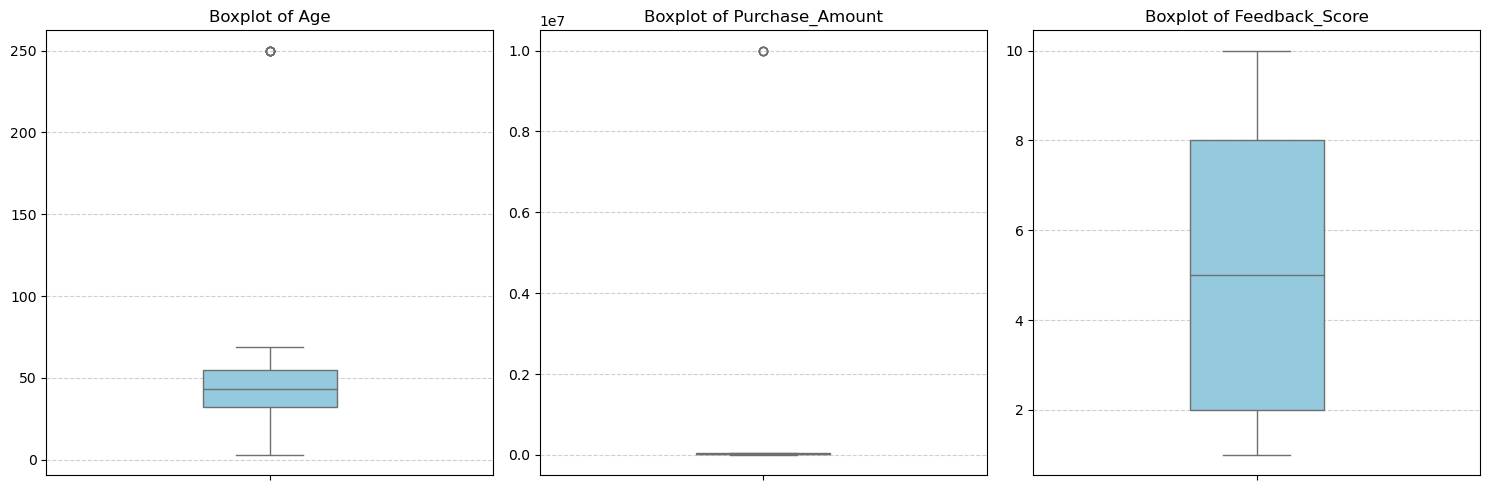

In [170]:
# To check the oulier using Boxplot

cols=['Age','Purchase_Amount','Feedback_Score']

plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):

 plt.subplot(1, 3, i)

 sns.boxplot(y=df[col], color='skyblue', width=0.3)

 plt.title(f'Boxplot of {col}', fontsize=12)

 plt.ylabel('')

 plt.grid(axis='y', linestyle='--', alpha=0.6) 

plt.tight_layout()

plt.show()

In [171]:
# Remove outlier using Z score 
from scipy import stats
z_score=np.abs(stats.zscore(df[['Age','Purchase_Amount']]))
z_score

,Age,Purchase_Amount
0,0.549258,0.010147
1,0.483992,0.071526
2,1.201918,0.012639
3,0.233935,0.050272
4,0.168669,0.022848
...,...,...
10193,1.147661,0.069167
10194,0.233935,0.028568
10195,0.560266,0.023328
10197,1.212927,0.070007


In [172]:
df_cleaned=df[~(z_score>3).any(axis=1)]
df_cleaned

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52,kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,india
1,CUST5957,Jason Thomas,male,51,kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,female,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,india
3,CUST2934,Brenda Pierce,female,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,female,41,chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,india
...,...,...,...,...,...,...,...,...,...,...,...,...
10193,CUST6352,Isaiah Terry,female,26,kolkata,2023-03-04,2025-06-30,43655.0,6.0,lopezleonard@example.net,7694723210,india
10194,CUST6146,Cody Thompson,female,40,kolkata,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,india
10195,CUST10767,Robert Lewis,female,35,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,india
10197,CUST6315,Joshua Martinez,male,25,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,india


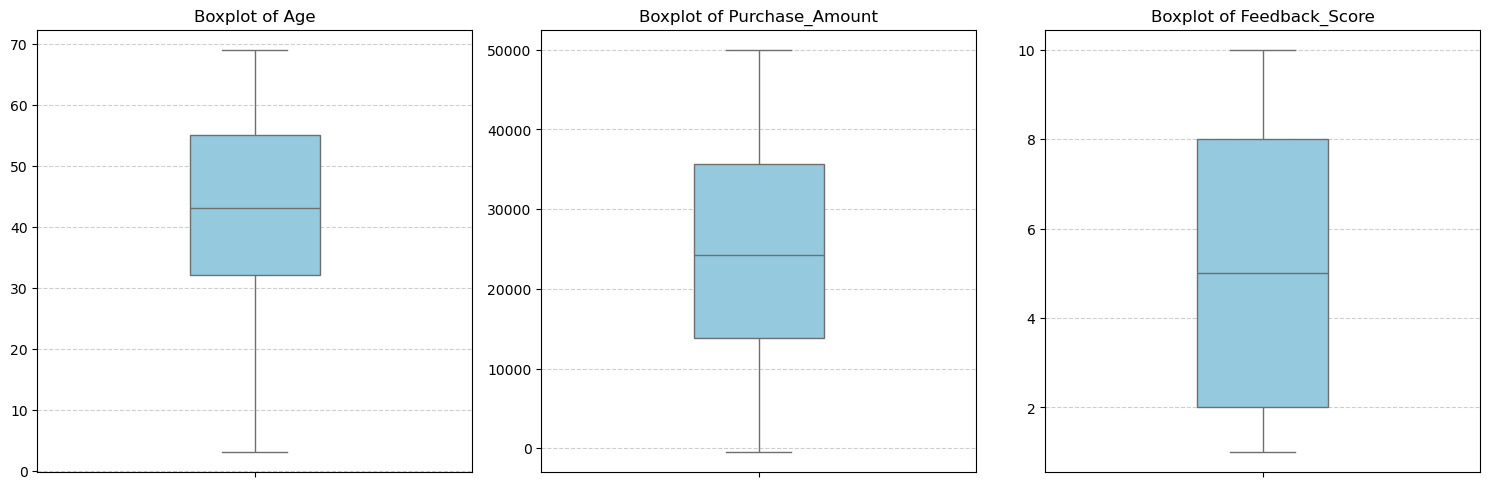

In [173]:
plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):

 plt.subplot(1, 3, i)

 sns.boxplot(y=df_cleaned[col], color='skyblue', width=0.3)

 plt.title(f'Boxplot of {col}', fontsize=12)

 plt.ylabel('')

 plt.grid(axis='y', linestyle='--', alpha=0.6) 

plt.tight_layout()

plt.show()